<a href="https://colab.research.google.com/github/ravichas/ds-project-template/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIFX-546: Machine Learning for Bioinformatics
## Notebook 1 — Exploratory Data Analysis (EDA)

**Project:** Predicting Hospital Readmission Risk from Clinical Indicators  
**Team Members:** John Doe  
**Course:** BIFX-546 · Hood College · Spring 2026  
**Instructor:** Dr. Sarangan Ravichandran

---

### Notebook Overview

This notebook covers:
1. Environment setup & library imports
2. Data loading (directly from UCI)
3. Initial data inspection
4. Data cleaning & preprocessing
5. Exploratory visualizations (3 plots)
6. Summary statistics

**Rubric checkpoint:** Progress Check-In #1 (Week 7)


## 1. Environment Setup

In [1]:
# Uncomment the line below only if running locally and packages are missing
# !pip install -r requirements.txt

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ------------------------------------------------------------------
# Path setup — works in both Colab and local Jupyter
#
# In Colab:  everything runs flat under /content/
#            figures save to /content/ during the session
#            a tidy-up cell at the end moves them into results/
#            before you download and upload to GitHub
#
# Local:     notebook sits inside notebooks/ in the cloned repo
#            figures save directly to ../results/
# ------------------------------------------------------------------
IN_COLAB = 'google.colab' in str(get_ipython().config if hasattr(__builtins__, '__import__') else '')
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

RESULTS_DIR = "results" if IN_COLAB else "../results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Environment : {'Google Colab' if IN_COLAB else 'Local Jupyter'}")
print(f"Figures will save to: {RESULTS_DIR}/")

# Consistent plot styling
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print()
print("All libraries loaded successfully.")
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"seaborn : {sns.__version__}")


Environment : Google Colab
Figures will save to: results/

All libraries loaded successfully.
pandas  : 2.2.2
numpy   : 2.0.2
seaborn : 0.13.2


## 2. Data Loading

We load the dataset directly from the UCI ML Repository.  
No manual download is needed — this cell works in Colab or local Jupyter.

**Dataset:** Diabetes 130-US Hospitals (1999–2008)  
**Source:** https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008


In [2]:
# Download dataset directly from UCI
# The ZIP contains two files; we extract only the main data file explicitly.
import io, zipfile, urllib.request

url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00296/dataset_diabetes.zip"
)

with urllib.request.urlopen(url) as response:
    zip_bytes = io.BytesIO(response.read())

with zipfile.ZipFile(zip_bytes) as z:
    print("Files in ZIP:", z.namelist())          # shows both CSVs
    with z.open("dataset_diabetes/diabetic_data.csv") as f:
        df_raw = pd.read_csv(f, na_values="?")

print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head(3)


Files in ZIP: ['dataset_diabetes/diabetic_data.csv', 'dataset_diabetes/IDs_mapping.csv']


/tmp/ipykernel_1130/1360471658.py:16: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(f, na_values="?")


Shape: 101,766 rows × 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


## 3. Initial Data Inspection

Before cleaning, we examine structure, data types, and missingness to
understand what preparation is needed.


In [3]:
# Column names and dtypes
print("=== Column dtypes ===")
print(df_raw.dtypes.value_counts())
print()

# Missing values — count and percent
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({"missing_n": missing, "missing_%": missing_pct})
missing_df = missing_df[missing_df["missing_n"] > 0].sort_values("missing_%", ascending=False)
print("=== Columns with missing values ===")
print(missing_df)


=== Column dtypes ===
object    37
int64     13
Name: count, dtype: int64

=== Columns with missing values ===
                   missing_n  missing_%
weight                 98569       96.9
max_glu_serum          96420       94.7
A1Cresult              84748       83.3
medical_specialty      49949       49.1
payer_code             40256       39.6
race                    2273        2.2
diag_3                  1423        1.4
diag_2                   358        0.4
diag_1                    21        0.0


In [4]:
# Inspect the target variable distribution
print("=== Readmission label counts ===")
print(df_raw["readmitted"].value_counts())
print()
print("Unique values:", df_raw["readmitted"].unique())


=== Readmission label counts ===
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Unique values: ['NO' '>30' '<30']


## 4. Data Cleaning & Preprocessing

**What we clean and why:**

| Step | Rationale |
|---|---|
| Drop `weight`, `payer_code`, `medical_specialty` | >40% missing; imputation would introduce too much noise |
| Drop duplicate `encounter_id` rows | Each row should represent one unique patient encounter |
| Recode `readmitted` to binary | Rubric requires a clear outcome variable; `<30` = 1 (early readmit), else = 0 |
| Remove `gender = Unknown/Invalid` | Only 3 rows; insufficient to model |
| Convert `age` bands to ordinal integers | Enables numeric correlation analysis |

These steps follow standard clinical data preprocessing practice.  
See [Strack et al. 2014] for rationale on feature exclusion in this dataset.


In [5]:
df = df_raw.copy()

# 1. Drop high-missingness columns
cols_to_drop = ["weight", "payer_code", "medical_specialty"]
df.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped {len(cols_to_drop)} high-missingness columns.")

# 2. Remove duplicate encounters (keep first)
n_before = len(df)
df.drop_duplicates(subset="encounter_id", keep="first", inplace=True)
print(f"Removed {n_before - len(df):,} duplicate encounters.")

# 3. Remove invalid gender entries
df = df[~df["gender"].isin(["Unknown/Invalid"])]
print(f"Rows after gender filter: {len(df):,}")

# 4. Recode target: 1 = readmitted within 30 days, 0 = not/later
df["readmitted_30d"] = (df["readmitted"] == "<30").astype(int)
print(f"Readmission rate (30-day): {df['readmitted_30d'].mean():.1%}")

# 5. Map age bands to ordinal midpoints
age_map = {
    "[0-10)": 5,  "[10-20)": 15, "[20-30)": 25, "[30-40)": 35,
    "[40-50)": 45, "[50-60)": 55, "[60-70)": 65, "[70-80)": 75,
    "[80-90)": 85, "[90-100)": 95
}
df["age_numeric"] = df["age"].map(age_map)

print(f"Final cleaned shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Dropped 3 high-missingness columns.
Removed 0 duplicate encounters.
Rows after gender filter: 101,763
Readmission rate (30-day): 11.2%
Final cleaned shape: 101,763 rows × 49 columns


In [6]:
# Confirm no remaining critical missing values
print("Remaining nulls in key columns:")
key_cols = ["age_numeric", "gender", "race", "number_diagnoses",
            "time_in_hospital", "num_medications", "readmitted_30d"]
print(df[key_cols].isnull().sum())


Remaining nulls in key columns:
age_numeric            0
gender                 0
race                2271
number_diagnoses       0
time_in_hospital       0
num_medications        0
readmitted_30d         0
dtype: int64


## 5. Exploratory Visualizations

Three plots are produced below, each addressing a specific aspect of the data.  
All plots are saved to `../results/` for inclusion in the repository.


### Plot 1 — 30-Day Readmission Rate by Age Group

**Question:** Do older patients have higher readmission rates?  
**Why this matters:** Age is a common proxy for comorbidity burden in clinical studies.


/tmp/ipykernel_1130/2627210887.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(readmit_by_age["age"], rotation=45, ha="right")


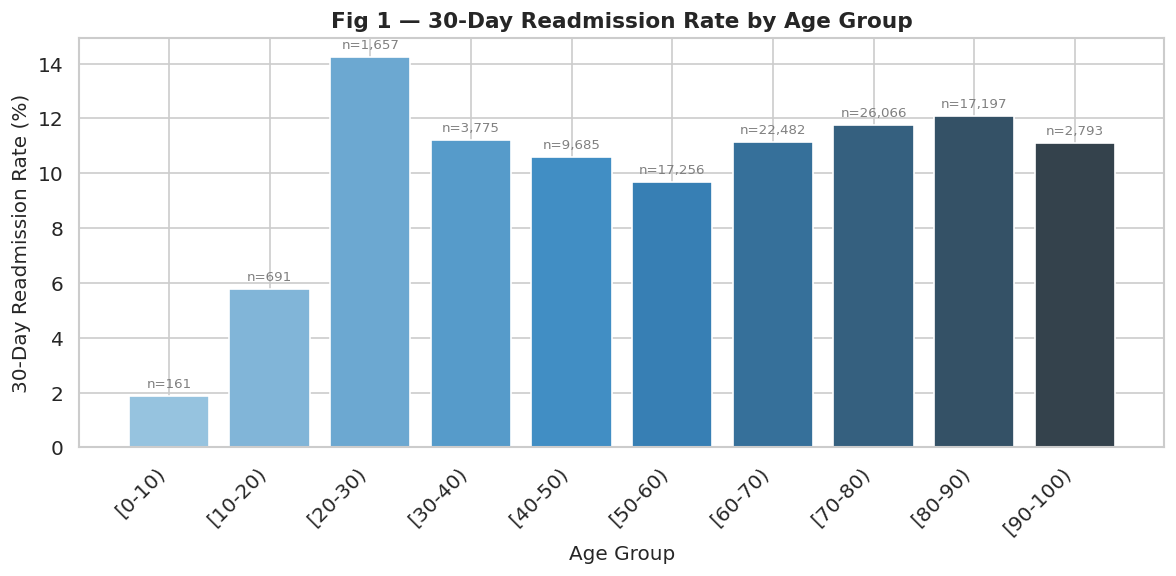

Saved → results/fig1_readmission_by_age.png


In [7]:
readmit_by_age = (
    df.groupby("age")["readmitted_30d"]
    .agg(rate="mean", count="count")
    .reset_index()
)

# Sort by age band order
age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]
readmit_by_age["age"] = pd.Categorical(readmit_by_age["age"], categories=age_order, ordered=True)
readmit_by_age = readmit_by_age.sort_values("age")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(readmit_by_age["age"], readmit_by_age["rate"] * 100,
              color=sns.color_palette("Blues_d", len(readmit_by_age)))

ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("30-Day Readmission Rate (%)", fontsize=12)
ax.set_title("Fig 1 — 30-Day Readmission Rate by Age Group", fontsize=13, fontweight="bold")
ax.set_xticklabels(readmit_by_age["age"], rotation=45, ha="right")

# Annotate bars with n
for bar, (_, row) in zip(bars, readmit_by_age.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f"n={row['count']:,}", ha="center", va="bottom", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig1_readmission_by_age.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR}/fig1_readmission_by_age.png")


### Plot 2 — Correlation Heatmap of Numeric Clinical Features

**Question:** Which clinical measurements are correlated with each other and with readmission?  
**Why this matters:** Identifying correlated features helps avoid redundancy in the model
and surfaces clinically meaningful relationships.


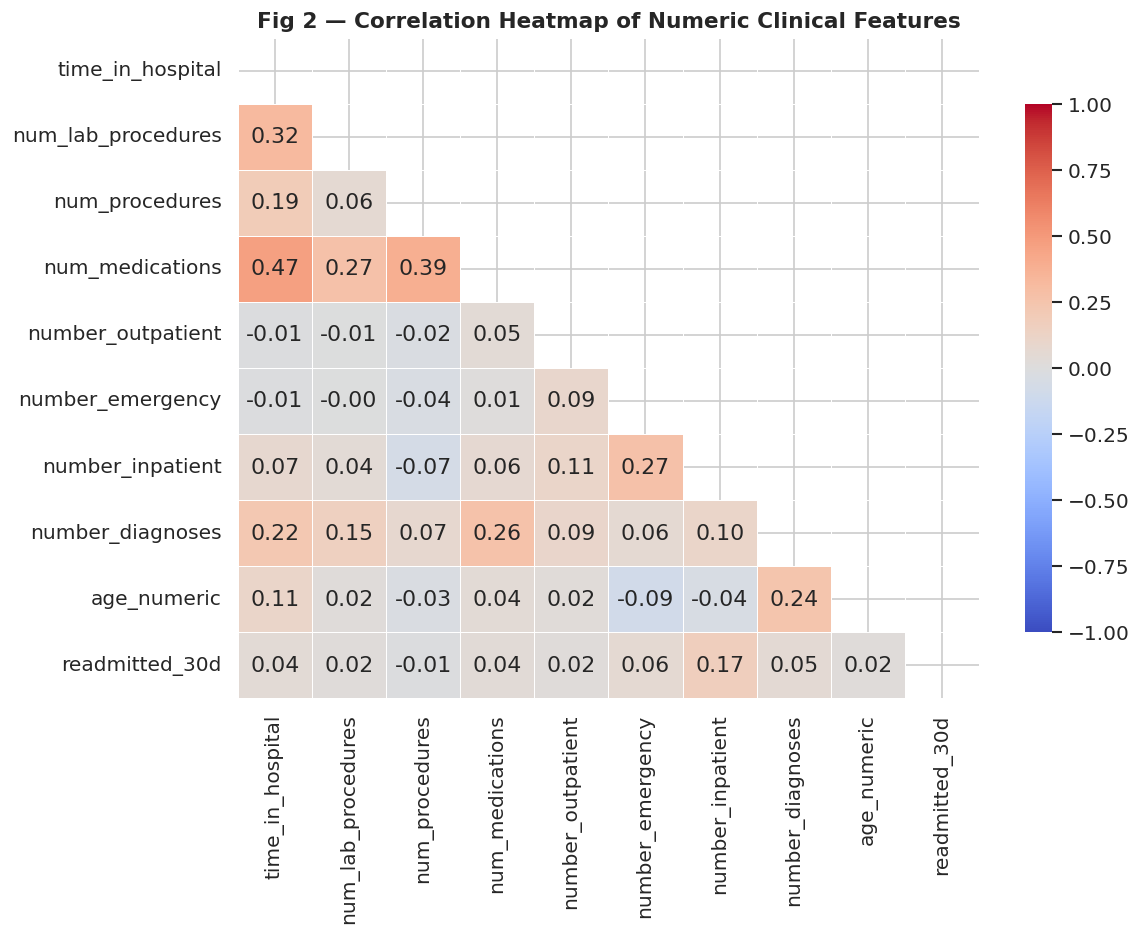

Saved → results/fig2_correlation_heatmap.png


In [8]:
numeric_cols = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses", "age_numeric", "readmitted_30d"
]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title("Fig 2 — Correlation Heatmap of Numeric Clinical Features",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig2_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR}/fig2_correlation_heatmap.png")


### Plot 3 — Distribution of Time in Hospital by Readmission Status

**Question:** Do patients readmitted within 30 days tend to have shorter or longer stays?  
**Why this matters:** Length of stay is a proxy for illness severity and may be a
confounding variable in readmission prediction.


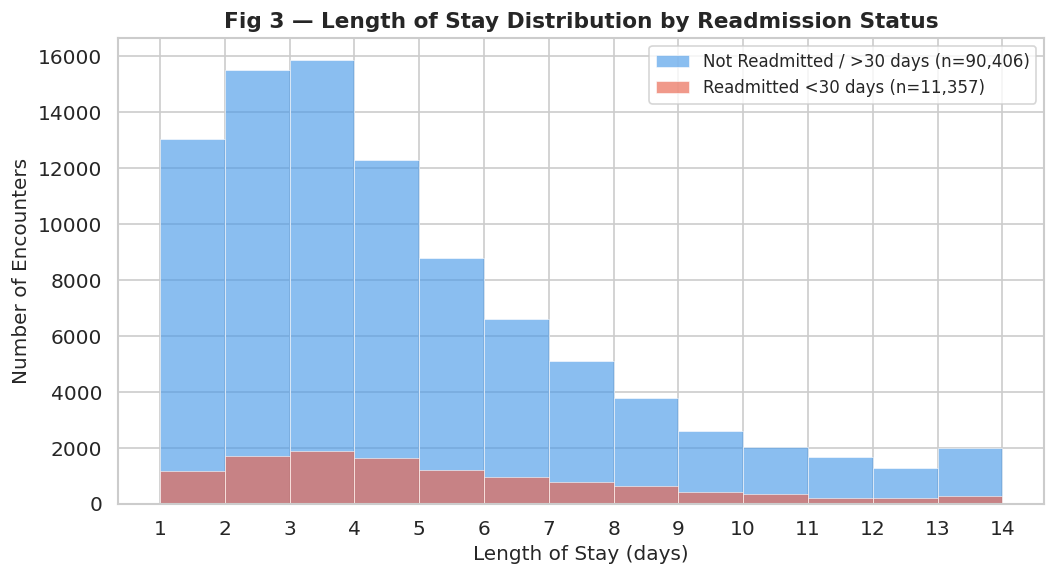

Saved → results/fig3_length_of_stay.png


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))

for label, color, name in [(0, "#4C9BE8", "Not Readmitted / >30 days"),
                            (1, "#E8634C", "Readmitted <30 days")]:
    subset = df[df["readmitted_30d"] == label]["time_in_hospital"]
    ax.hist(subset, bins=range(1, 15), alpha=0.65, color=color,
            label=f"{name} (n={len(subset):,})", edgecolor="white", linewidth=0.5)

ax.set_xlabel("Length of Stay (days)", fontsize=12)
ax.set_ylabel("Number of Encounters", fontsize=12)
ax.set_title("Fig 3 — Length of Stay Distribution by Readmission Status",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xticks(range(1, 15))
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig3_length_of_stay.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR}/fig3_length_of_stay.png")


## 6. Summary Statistics

Key descriptive statistics for the numeric clinical features,
stratified by readmission status.


In [10]:
summary_cols = [
    "time_in_hospital", "num_lab_procedures", "num_medications",
    "number_inpatient", "number_diagnoses", "age_numeric"
]

summary = df.groupby("readmitted_30d")[summary_cols].agg(["mean", "median", "std"]).round(2)
summary.index = ["Not readmitted / >30d", "Readmitted <30d"]
print("=== Summary Statistics by Readmission Status ===")
summary


=== Summary Statistics by Readmission Status ===


time_in_hospital              num_lab_procedures         \
                                  mean median   std               mean median   
Not readmitted / >30d             4.35    4.0  2.98              42.95   44.0   
Readmitted <30d                   4.77    4.0  3.03              44.23   45.0   

                             num_medications              number_inpatient  \
                         std            mean median   std             mean   
Not readmitted / >30d  19.72           15.91   15.0  8.12             0.56   
Readmitted <30d        19.28           16.90   16.0  8.10             1.22   

                                   number_diagnoses              age_numeric  \
                      median   std             mean median   std        mean   
Not readmitted / >30d    0.0  1.13             7.39    8.0  1.95       65.87   
Readmitted <30d          0.0  1.95             7.69    9.0  1.77       66.76   

                                     
                      median    std  
Not readmitted / >30d   65.0  15.96  
Readmitted <30d         65.0  15.78

In [11]:
# Overall readmission statistics
print("=== Overall Dataset Summary ===")
print(f"Total encounters      : {len(df):,}")
print(f"30-day readmissions   : {df['readmitted_30d'].sum():,} ({df['readmitted_30d'].mean():.1%})")
print(f"Avg length of stay    : {df['time_in_hospital'].mean():.1f} days "
      f"(median {df['time_in_hospital'].median():.0f})")
print(f"Avg medications       : {df['num_medications'].mean():.1f}")
print(f"Avg diagnoses         : {df['number_diagnoses'].mean():.1f}")
print(f"Avg prior inpatient   : {df['number_inpatient'].mean():.2f}")


=== Overall Dataset Summary ===
Total encounters      : 101,763
30-day readmissions   : 11,357 (11.2%)
Avg length of stay    : 4.4 days (median 4)
Avg medications       : 16.0
Avg diagnoses         : 7.4
Avg prior inpatient   : 0.64


## 7. Progress Note & Next Steps

**What we completed in this notebook:**
- Loaded 101,766 encounter records directly from UCI (no manual download needed)
- Cleaned data: dropped 3 high-missingness columns, removed duplicates and invalid entries
- Recoded the target variable to binary (30-day readmission: yes/no)
- Produced 3 labeled visualizations addressing age, feature correlation, and length of stay
- Computed summary statistics stratified by readmission outcome

**Key early observations:**
- Overall 30-day readmission rate is approximately 11%
- Readmitted patients have more prior inpatient visits and more diagnoses on average
- Age group 70–80 shows the highest readmission rate
- `number_inpatient` (prior hospitalizations) has the strongest positive correlation with readmission

**Next steps (Notebook 02 — Hypothesis Testing):**
- Chi-square test: Is readmission rate significantly different across primary diagnosis groups?
- Bootstrap confidence intervals on the overall readmission rate
- Mann-Whitney U test: Is time-in-hospital distribution significantly different between groups?

**Next steps (Notebook 03 — Modeling):**
- Logistic Regression with train/test split (80/20)
- Decision Tree for feature importance comparison
- Evaluation: Accuracy, Precision, Recall, AUC-ROC


## 8. Tidy Up & Upload to GitHub

When you are done running all cells, follow these steps to get your work
into your GitHub repository — no `git` commands needed.

### Step 1 — Save this notebook
In the Colab menu: **File → Save** (`Ctrl+S` / `Cmd+S`).

---

### Step 2 — Run the tidy-up cell below
This moves all saved figures into a `results/` subfolder so your downloads
mirror the GitHub repo structure exactly.

---

### Step 3 — Download files from Colab
The download cell will prompt you to save each file to your computer.

---

### Step 4 — Upload to GitHub in your browser
Do this **separately** for each folder:

1. Go to your GitHub repository
2. Navigate into `notebooks/` → **Add file → Upload files** → drag `01_eda.ipynb` → **Commit changes**
3. Navigate into `results/` → **Add file → Upload files** → drag the `.png` files → **Commit changes**

> If a file already exists, GitHub will ask you to confirm the overwrite — click **Commit changes**.


In [12]:
# ── Tidy-up: only needed in Colab ─────────────────────────────────────
# Moves figures from flat /content/ into results/ so downloads match
# the GitHub repo structure. Safe to re-run.
if IN_COLAB:
    os.makedirs("results", exist_ok=True)
    for png in glob.glob("*.png"):
        dest = os.path.join("results", os.path.basename(png))
        os.rename(png, dest)
        print(f"Moved {png} → {dest}")

# ── Download notebook ──────────────────────────────────────────────────────
if IN_COLAB:
    notebook_name = "01_eda.ipynb"
    if os.path.exists(notebook_name):
        files.download(notebook_name)
        print(f"Downloading {notebook_name} → upload to notebooks/ on GitHub")
    else:
        print("Notebook not found — go to File → Save first, then re-run this cell.")

    # ── Download figures ───────────────────────────────────────────────────
    figs = glob.glob("results/*.png")
    if figs:
        for fig in sorted(figs):
            files.download(fig)
            print(f"Downloading {fig} → upload to results/ on GitHub")
    else:
        print("No figures found in results/ — check that the plot cells ran successfully.")
else:
    print("Local Jupyter: files already saved to ../results/ — no download step needed.")


Notebook not found — go to File → Save first, then re-run this cell.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Step 4 — Upload files to GitHub in your browser

Do this separately for **notebooks/** and **results/**:

1. Go to your GitHub repository in your browser
2. Navigate into the target folder (e.g. click `notebooks/`)
3. Click **Add file → Upload files**
4. Drag and drop the downloaded file(s) — `01_eda.ipynb` into `notebooks/`, `.png` files into `results/`
5. Scroll down, add a short commit message (e.g. `Add EDA notebook and figures`)
6. Click **Commit changes**

> **Tip:** If a file already exists in the folder, GitHub will ask you to confirm  
> the overwrite — click **Commit changes** to save the updated version.

---

That's it — no `git` commands needed.
